In [33]:
import sys
sys.path.insert(0, "/home/syedkazim/sciebo - Kazim, Syed Muhammad (u491036@uni-siegen.de)@uni-siegen.sciebo.de/Lab/Projects/2024_Phase_Camera_FM_Design/coded_wfs_sim")

from coded_wfs_sim import geometry
from coded_wfs_sim import propagator
from coded_wfs_sim import visualization
from coded_wfs_sim import utils

import numpy as np
from tifffile import tifffile
from matplotlib import pyplot as plt
import cv2
import torch
import torch.nn.functional as F

from scipy.ndimage import gaussian_filter
from scipy.signal import correlate2d, convolve2d, tukey
from scipy.interpolate import RegularGridInterpolator
import scipy

from orthnet import Legendre

# See the effects of partial spatial coherence on speckle field

* Reference plus object speckles; phase retrieval using flow and forward operator
* using memory effect as a regularizer?

Steps:
* Create a T matrix for a random phase pattern. Using random phase screen modeling.
* Make well defined object waves. Local curvatures.
* Optimize

To try:
1. Combining the data term and regularization on phase terms with optical flow

In [2]:
# set system params

# Grid and propagation parameters setup
wl = 640e-9 # meters
n_0 = 1.

dx = 500e-9 # dx == dy
nx = 2000 # nx == ny

padding = 512
dist = 3e-3 # distance bw phase mask and image plane 

(3024,) float64 20 100


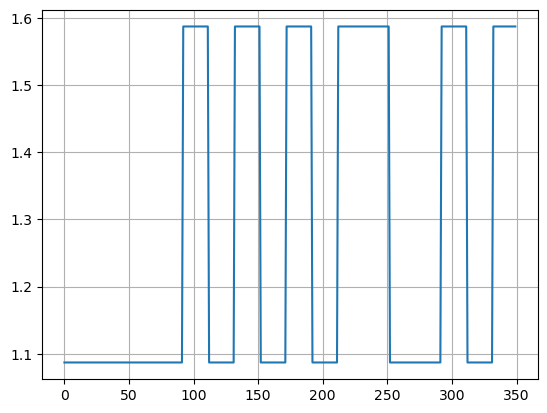

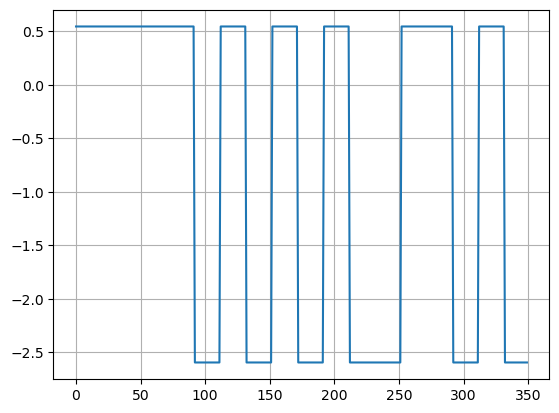

(torch.Size([3024, 3024]),
 <function Tensor.type>,
 tensor([[0.8544+0.5196j, 0.0000+0.0000j, 0.0000+0.0000j, 0.0000+0.0000j],
         [0.0000+0.0000j, 0.8544+0.5196j, 0.0000+0.0000j, 0.0000+0.0000j],
         [0.0000+0.0000j, 0.0000+0.0000j, 0.8544+0.5196j, 0.0000+0.0000j],
         [0.0000+0.0000j, 0.0000+0.0000j, 0.0000+0.0000j, 0.8544+0.5196j]],
        dtype=torch.complex128))

In [3]:
# create phase mask: 
# diagonal phase-only transmission matrix

side_length = 10e-6
tile_size = int(side_length/dx)
RI_pm = 1.46
height = wl/(2*(RI_pm - n_0))#695e-9 # \pi = 2\pi /wl * (RI_pm - 1)*h => h = wl/(2*(RI_pm - n_0))
prob = 0.5

nx_tiles = nx//tile_size
samples_mask = np.random.uniform(size=nx_tiles) > prob

# strucutres size-distance away from boundary
samples_mask[0] = 0.
samples_mask[-1] = 0.

h_map_pm = height*np.repeat(samples_mask, tile_size, axis=0)
h_map_pm = np.pad(h_map_pm, padding, 'edge')

opd_pm = h_map_pm*RI_pm + (h_map_pm.max() - h_map_pm)*n_0
t_diag = np.exp(1j*(2*np.pi/wl)*opd_pm) # no negative sign

print(h_map_pm.shape, h_map_pm.dtype, tile_size, nx_tiles)

plt.plot(opd_pm[500:850]/wl)
plt.grid()
plt.show()

plt.plot(np.angle(t_diag[500:850]))
plt.grid()
plt.show()

T_d = torch.diag(torch.from_numpy(t_diag))
T_d.shape, T_d.type, T_d[:4, :4]


torch.Size([2512, 2512]) torch.complex64 tensor([[-1.0000-0.0005j,  0.0000+0.0000j,  0.0000+0.0000j,  0.0000+0.0000j],
        [ 0.0000+0.0000j, -1.0000+0.0034j,  0.0000+0.0000j,  0.0000+0.0000j],
        [ 0.0000+0.0000j,  0.0000+0.0000j, -0.9999+0.0151j,  0.0000+0.0000j],
        [ 0.0000+0.0000j,  0.0000+0.0000j,  0.0000+0.0000j, -0.9995+0.0327j]])


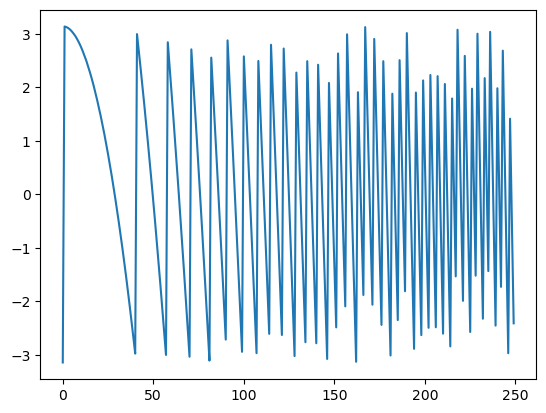

In [4]:
# create phase modulation diagnoal matrix that is a function of distance z

def prop_phase_matrix(field, dist, wl, dx):

        k0 = 2 * torch.pi / wl
        Nx = field.shape[0]

        kx = torch.fft.fftfreq(Nx, dx) * 2 * torch.pi
        kz = torch.sqrt(k0**2 - kx**2)
        
        return torch.diag(torch.exp(1j*kz*dist))

M_z = prop_phase_matrix(torch.ones(2512), dist, wl, dx)

print(M_z.shape, M_z.dtype, M_z[:4, :4])
plt.plot(torch.angle(M_z.diag())[:250])

In [5]:
# 1d propagator

def propagate_1d(field, dist, wl, dx):

        k0 = 2 * torch.pi / wl
        Nx = field.shape[0]

        kx = torch.fft.fftfreq(Nx, dx) * 2 * torch.pi
        kz = torch.sqrt(k0**2 - kx**2)

        field_fft = torch.fft.fft(field)
        transfer_function = torch.exp(1j*kz*dist)
        out_field = torch.fft.ifft(field_fft * transfer_function)
        
        return out_field

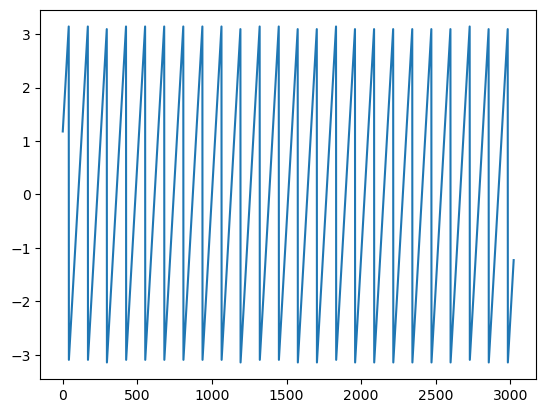

In [6]:
x_cords = torch.arange(-1*(nx/2 + padding) , nx/2 + padding)*dx
field = torch.exp(1j* 2 * torch.pi / wl * 0.01*x_cords)
plt.plot(torch.angle(field.clone().detach()))

In [7]:
np.sin(1/100)/2.355, np.sin(5/100)/2.355, np.sin(10/100)/2.355

(0.004246213730007076, 0.021222577185001413, 0.04239210897954487)

In [69]:
# # np.sin(1/100)/2.355

# u_io_r_w_1 = torch.zeros([101, T_d.shape[1]], dtype=torch.float64)
# x_cords = torch.arange(-1*(nx/2 + padding) , nx/2 + padding)*dx

# for idx, z in enumerate(np.linspace(0, 5, 101)):
#     print(idx)
#     for _ in range(100):
#         w = np.random.normal(wl, 5e-9)
#         for _ in range(100):
#             angle = np.random.normal(0, np.sin(1/100)/2.355)
#             field_phase = 1j* 2 * torch.pi * angle * x_cords / wl
#             field = torch.exp(field_phase)
#             u_io_r_w_1[idx] += np.abs(propagate_1d(torch.matmul(T_d, field.cdouble()), z*1e-3, w, dx))**2



# fig, axs = plt.subplots(1, figsize=(20, 4))

# cm0 = axs.imshow(np.log10((u_io_r_w_1[:, 1012:2012]/101)), cmap='jet', extent=[-1*dx*(nx/2 + padding)*1e4, dx*(nx/2 + padding)*1e4, 5, 0])
# plt.colorbar(cm0, ax=axs)
# axs.set_ylabel('Propagation [mm]')
# axs.set_xlabel('Lateral [1e-4 m]')
# axs.set_title('Intensity')
# plt.show()

In [70]:
# # np.sin(5/100)/2.355

# u_io_r_w_5 = torch.zeros([101, T_d.shape[1]], dtype=torch.float64)
# x_cords = torch.arange(-1*(nx/2 + padding) , nx/2 + padding)*dx

# for idx, z in enumerate(np.linspace(0, 5, 101)):
#     print(idx)
#     for _ in range(100):
#         w = np.random.normal(wl, 5e-9)
#         for _ in range(100):
#             angle = np.random.normal(0, np.sin(0.1/100)/2.355)
#             field_phase = 1j* 2 * torch.pi * angle * x_cords / wl
#             field = torch.exp(field_phase)
#             u_io_r_w_5[idx] += np.abs(propagate_1d(torch.matmul(T_d, field.cdouble()), z*1e-3, w, dx))**2



# fig, axs = plt.subplots(1, figsize=(20, 4))

# cm0 = axs.imshow(np.log10((u_io_r_w_5[:, 1012:2012]/101)), cmap='jet', extent=[-1*dx*(nx/2 + padding)*1e4, dx*(nx/2 + padding)*1e4, 5, 0])
# plt.colorbar(cm0, ax=axs)
# axs.set_ylabel('Propagation [mm]')
# axs.set_xlabel('Lateral [1e-4 m]')
# axs.set_title('Intensity')
# plt.show()

In [71]:
# # np.sin(10/100)/2.355

# u_io_r_w_10 = torch.zeros([101, T_d.shape[1]], dtype=torch.float64)
# x_cords = torch.arange(-1*(nx/2 + padding) , nx/2 + padding)*dx

# for idx, z in enumerate(np.linspace(0, 5, 101)):
#     print(idx)
#     for _ in range(100):
#         w = np.random.normal(wl, 5e-9)
#         for _ in range(100):
#             angle = np.random.normal(0, np.sin(0.01/100)/2.355)
#             field_phase = 1j* 2 * torch.pi * angle * x_cords / wl
#             field = torch.exp(field_phase)
#             u_io_r_w_10[idx] += np.abs(propagate_1d(torch.matmul(T_d, field.cdouble()), z*1e-3, w, dx))**2



# fig, axs = plt.subplots(1, figsize=(20, 4))

# cm0 = axs.imshow(np.log10((u_io_r_w_10[:, 1012:2012]/101)), cmap='jet', extent=[-1*dx*(nx/2 + padding)*1e4, dx*(nx/2 + padding)*1e4, 5, 0])
# plt.colorbar(cm0, ax=axs)
# axs.set_ylabel('Propagation [mm]')
# axs.set_xlabel('Lateral [1e-4 m]')
# axs.set_title('Intensity')
# plt.show()

In [72]:
# u_io_r = torch.zeros([101, T_d.shape[1]], dtype=torch.complex128)

# for idx, z in enumerate(np.linspace(0, 5, 101)):
#     u_io_r[idx] = propagate_1d(T_d.diag(), z*1e-3, wl, dx)
    
# fig, axs = plt.subplots(1, figsize=(20, 4))

# cm0 = axs.imshow(np.log10(torch.abs(u_io_r[:, 1012:2012])**2), cmap='jet', extent=[-1*dx*(nx/2 + padding)*1e4, dx*(nx/2 + padding)*1e4, 5, 0])
# plt.colorbar(cm0, ax=axs)
# axs.set_ylabel('Propagation [mm]')
# axs.set_xlabel('Lateral [1e-4 m]')
# axs.set_title('Intensity')
# plt.show()

In [65]:
# scipy.io.savemat('v14/coherent_part_1e-2_sim_0-5mm.mat',
#                  {
#                      'intensity': u_io_r_w_10.numpy()/101**2,
#                      'dist': '0-5_mm',
#                      'angles': 'N(0, np.sin(0.01/100)/2.355)',
#                      'wavelength': 'N(640_nm, 5_nm)',
#                      'details': 'Partially coherent incident reference plane wave modulated by a random phase mask with imaging plane at 0-5 mm away.',
#                      'date': '2025_06_23'
#                  }
# )

u_io_r = scipy.io.loadmat('v14/coherent_sim_0-5mm.mat')['intensity']
u_io_r_w_1 = scipy.io.loadmat('v14/coherent_part_1e0_sim_0-5mm.mat')['intensity']
u_io_r_w_5 = scipy.io.loadmat('v14/coherent_part_1e-1_sim_0-5mm.mat')['intensity']
u_io_r_w_10 = scipy.io.loadmat('v14/coherent_part_1e-2_sim_0-5mm.mat')['intensity']


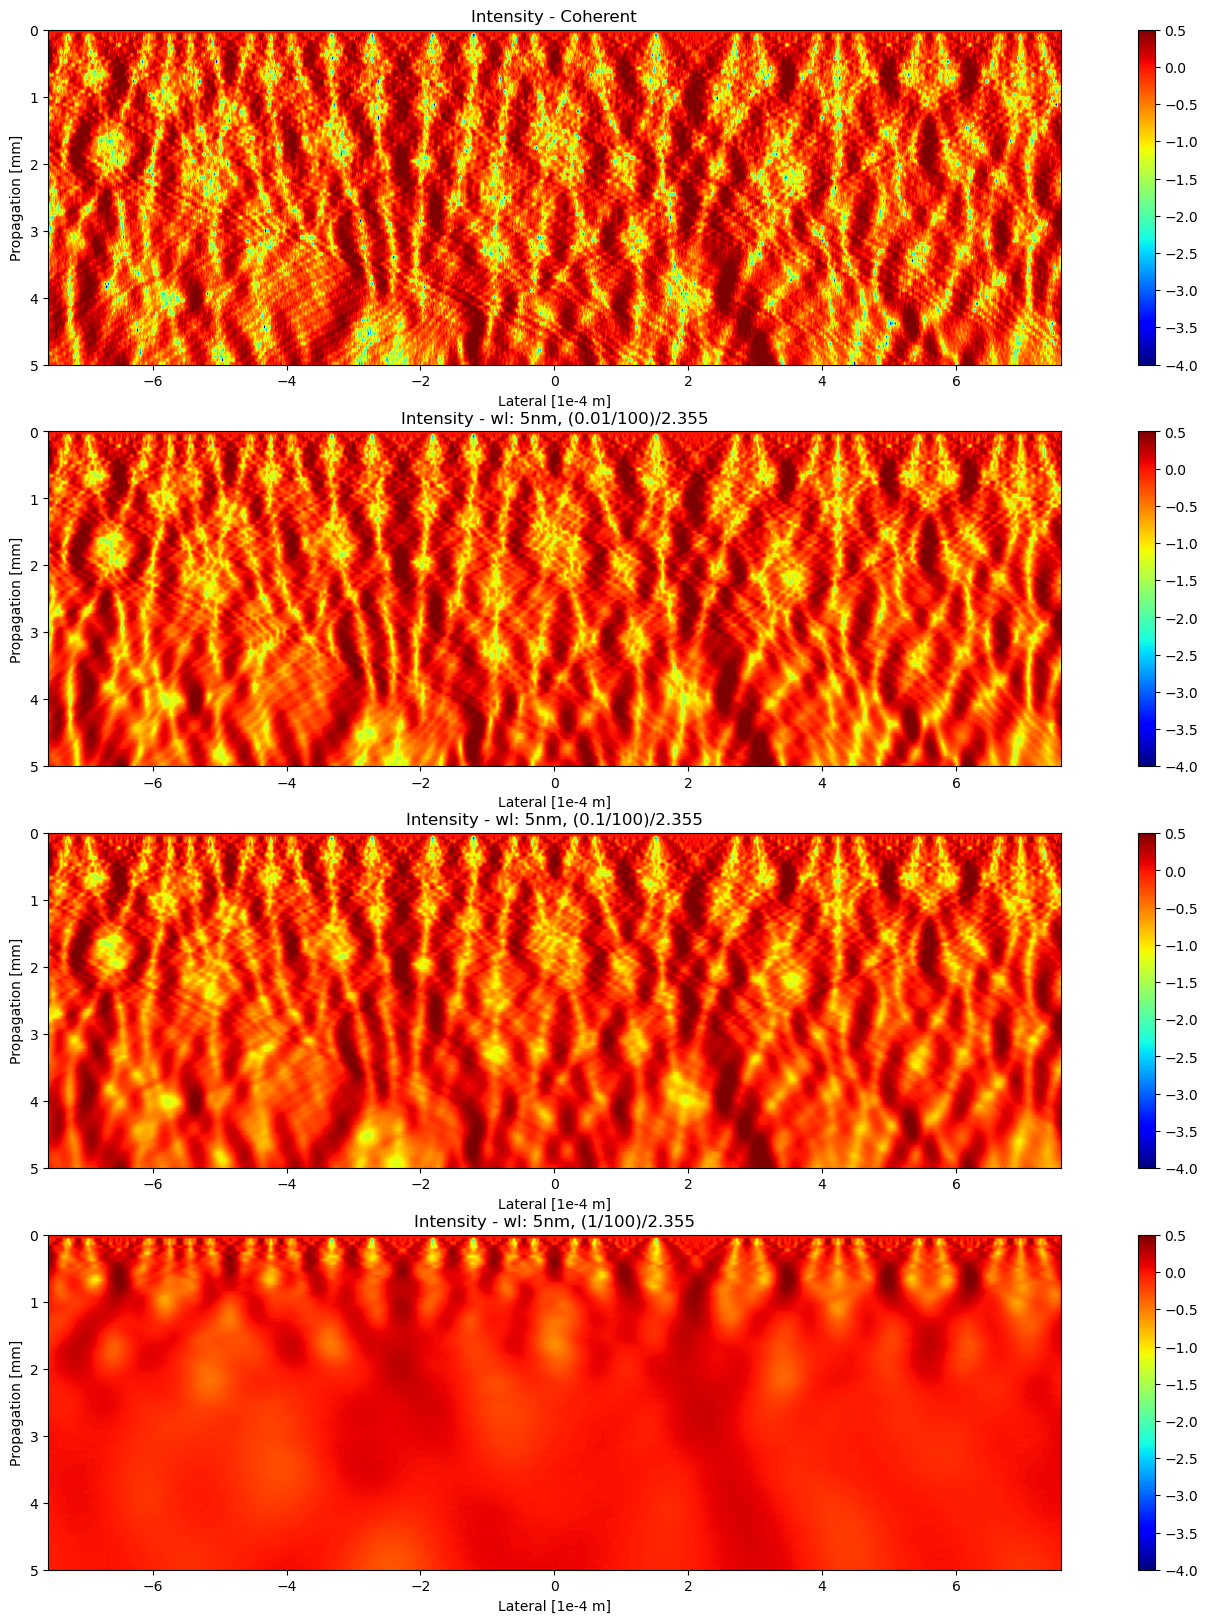

In [67]:
fig, axs = plt.subplots(4, 1, figsize=(20, 20))

cm0 = axs[0].imshow(np.log10((u_io_r[:, 1012:2012])), cmap='jet', 
                    extent=[-1*dx*(nx/2 + padding)*1e4, dx*(nx/2 + padding)*1e4, 5, 0],
                    vmax=0.5, vmin=-4)
plt.colorbar(cm0, ax=axs[0])
axs[0].set_ylabel('Propagation [mm]')
axs[0].set_xlabel('Lateral [1e-4 m]')
axs[0].set_title('Intensity - Coherent')

cm1 = axs[1].imshow(np.log10((u_io_r_w_10[:, 1012:2012])), cmap='jet', 
                    extent=[-1*dx*(nx/2 + padding)*1e4, dx*(nx/2 + padding)*1e4, 5, 0],
                    vmax=0.5, vmin=-4)
plt.colorbar(cm1, ax=axs[1])
axs[1].set_ylabel('Propagation [mm]')
axs[1].set_xlabel('Lateral [1e-4 m]')
axs[1].set_title('Intensity - wl: 5nm, (0.01/100)/2.355')

cm2 = axs[2].imshow(np.log10((u_io_r_w_5[:, 1012:2012])), cmap='jet', 
                    extent=[-1*dx*(nx/2 + padding)*1e4, dx*(nx/2 + padding)*1e4, 5, 0],
                    vmax=0.5, vmin=-4)
plt.colorbar(cm2, ax=axs[2])
axs[2].set_ylabel('Propagation [mm]')
axs[2].set_xlabel('Lateral [1e-4 m]')
axs[2].set_title('Intensity - wl: 5nm, (0.1/100)/2.355')

cm3 = axs[3].imshow(np.log10((u_io_r_w_1[:, 1012:2012])), cmap='jet', 
                    extent=[-1*dx*(nx/2 + padding)*1e4, dx*(nx/2 + padding)*1e4, 5, 0],
                    vmax=0.5, vmin=-4)
plt.colorbar(cm3, ax=axs[3])
axs[3].set_ylabel('Propagation [mm]')
axs[3].set_xlabel('Lateral [1e-4 m]')
axs[3].set_title('Intensity - wl: 5nm, (1/100)/2.355')

plt.show()

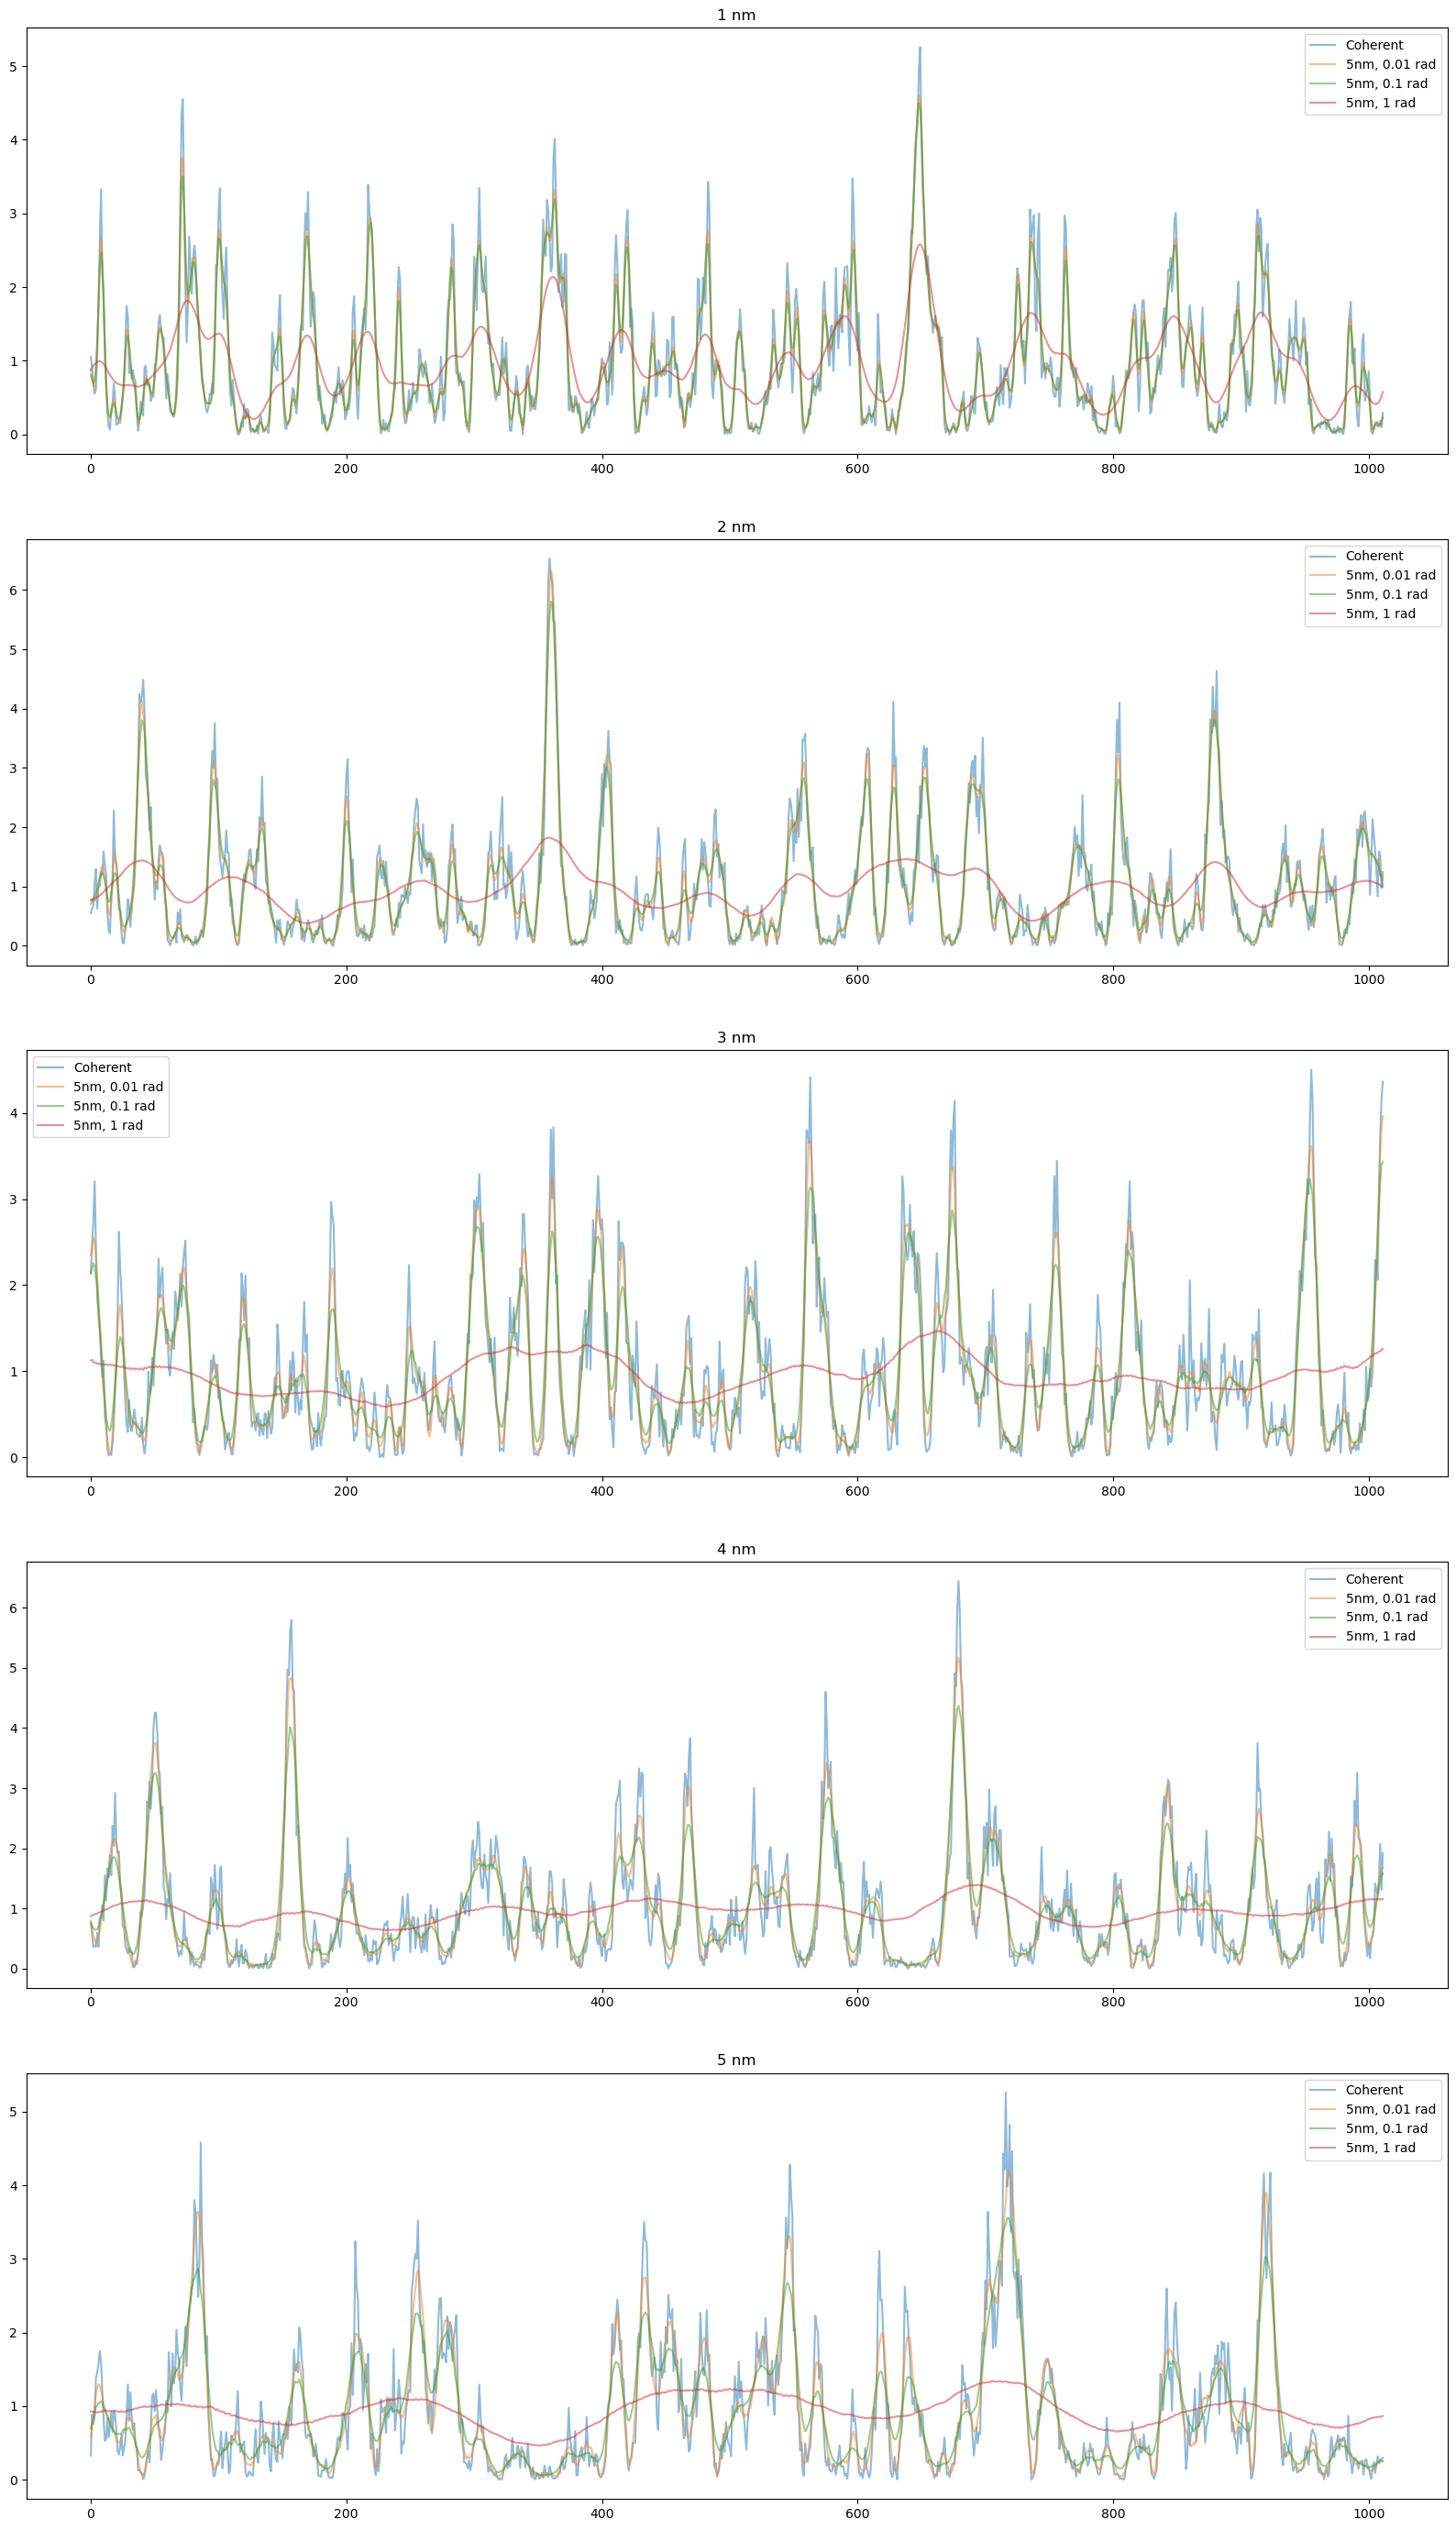

In [68]:
fig, axs = plt.subplots(5, 1, figsize=(20, 35))


axs[0].plot(np.abs(u_io_r[20, 1000:2012]), alpha=0.5, label="Coherent")
axs[0].plot((u_io_r_w_10[20, 1000:2012]), alpha=0.5, label="5nm, 0.01 rad")
axs[0].plot((u_io_r_w_5[20, 1000:2012]), alpha=0.5, label="5nm, 0.1 rad")
axs[0].plot((u_io_r_w_1[20, 1000:2012]), alpha=0.5, label="5nm, 1 rad")

axs[0].set_title('1 nm')
axs[0].legend()

axs[1].plot(np.abs(u_io_r[40, 1000:2012]), alpha=0.5, label="Coherent")
axs[1].plot((u_io_r_w_10[40, 1000:2012]), alpha=0.5, label="5nm, 0.01 rad")
axs[1].plot((u_io_r_w_5[40, 1000:2012]), alpha=0.5, label="5nm, 0.1 rad")
axs[1].plot((u_io_r_w_1[40, 1000:2012]), alpha=0.5, label="5nm, 1 rad")

axs[1].set_title('2 nm')
axs[1].legend()

axs[2].plot(np.abs(u_io_r[60, 1000:2012]), alpha=0.5, label="Coherent")
axs[2].plot((u_io_r_w_10[60, 1000:2012]), alpha=0.5, label="5nm, 0.01 rad")
axs[2].plot((u_io_r_w_5[60, 1000:2012]), alpha=0.5, label="5nm, 0.1 rad")
axs[2].plot((u_io_r_w_1[60, 1000:2012]), alpha=0.5, label="5nm, 1 rad")

axs[2].set_title('3 nm')
axs[2].legend()

axs[3].plot(np.abs(u_io_r[80, 1000:2012]), alpha=0.5, label="Coherent")
axs[3].plot((u_io_r_w_10[80, 1000:2012]), alpha=0.5, label="5nm, 0.01 rad")
axs[3].plot((u_io_r_w_5[80, 1000:2012]), alpha=0.5, label="5nm, 0.1 rad")
axs[3].plot((u_io_r_w_1[80, 1000:2012]), alpha=0.5, label="5nm, 1 rad")

axs[3].set_title('4 nm')
axs[3].legend()

axs[4].plot(np.abs(u_io_r[100, 1000:2012]), alpha=0.5, label="Coherent")
axs[4].plot((u_io_r_w_10[100, 1000:2012]), alpha=0.5, label="5nm, 0.01 rad")
axs[4].plot((u_io_r_w_5[100, 1000:2012]), alpha=0.5, label="5nm, 0.1 rad")
axs[4].plot((u_io_r_w_1[100, 1000:2012]), alpha=0.5, label="5nm, 1 rad")

axs[4].set_title('5 nm')
axs[4].legend()

plt.show()

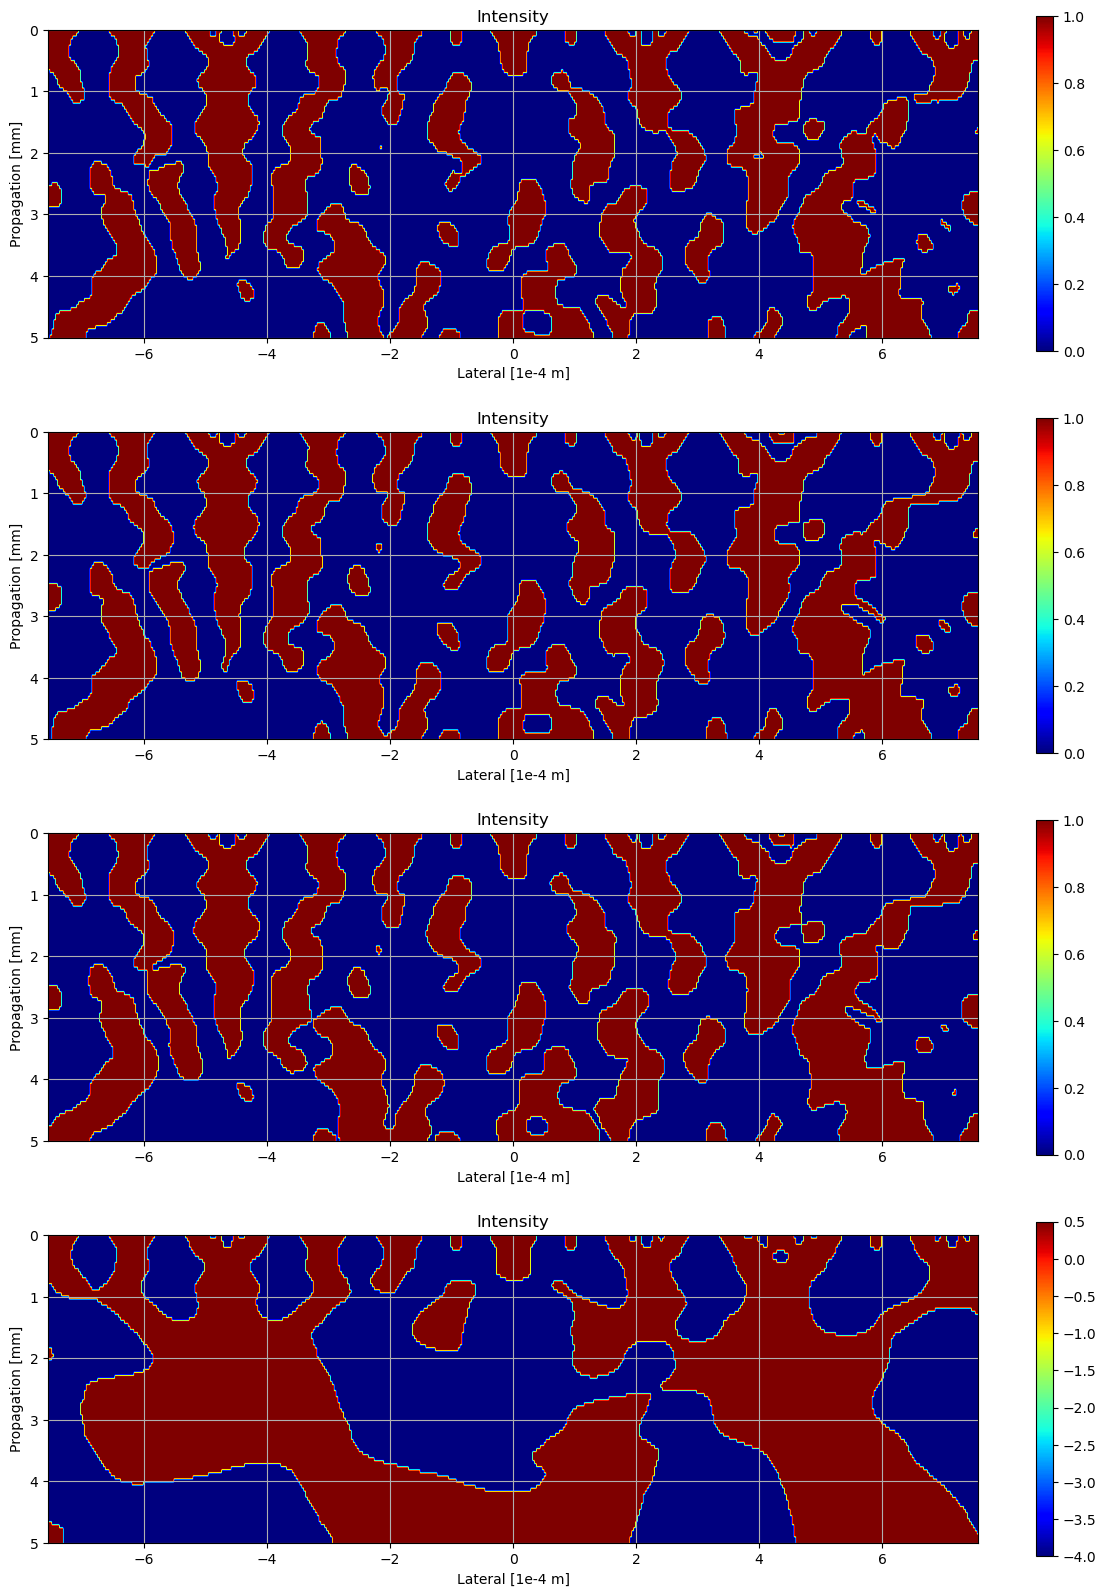

In [84]:
fig, axs = plt.subplots(4, 1, figsize=(15, 20))

cm0 = axs[0].imshow(gaussian_filter(np.log10((u_io_r[:, 1012+256:-256+2012])), 2)>0, cmap='jet', extent=[-1*dx*(nx/2 + padding)*1e4, dx*(nx/2 + padding)*1e4, 5, 0])
plt.colorbar(cm0, ax=axs[0])
axs[0].set_ylabel('Propagation [mm]')
axs[0].set_xlabel('Lateral [1e-4 m]')
axs[0].set_title('Intensity')
axs[0].grid()

cm1 = axs[1].imshow(gaussian_filter(np.log10((u_io_r_w_10[:, 1012+256:-256+2012])), 2)>0, cmap='jet', extent=[-1*dx*(nx/2 + padding)*1e4, dx*(nx/2 + padding)*1e4, 5, 0])
plt.colorbar(cm1, ax=axs[1])
axs[1].set_ylabel('Propagation [mm]')
axs[1].set_xlabel('Lateral [1e-4 m]')
axs[1].set_title('Intensity')
axs[1].grid()

cm2 = axs[2].imshow(gaussian_filter(np.log10((u_io_r_w_5[:, 1012+256:-256+2012])), 2)>0, cmap='jet', extent=[-1*dx*(nx/2 + padding)*1e4, dx*(nx/2 + padding)*1e4, 5, 0])
plt.colorbar(cm2, ax=axs[2])
axs[2].set_ylabel('Propagation [mm]')
axs[2].set_xlabel('Lateral [1e-4 m]')
axs[2].set_title('Intensity')
axs[2].grid()

cm0 = axs[3].imshow(gaussian_filter(np.log10((u_io_r_w_1[:, 1012+256:-256+2012])), 2)>0, cmap='jet', extent=[-1*dx*(nx/2 + padding)*1e4, dx*(nx/2 + padding)*1e4, 5, 0])
plt.colorbar(cm3, ax=axs[3])
axs[3].set_ylabel('Propagation [mm]')
axs[3].set_xlabel('Lateral [1e-4 m]')
axs[3].set_title('Intensity')
axs[3].grid()

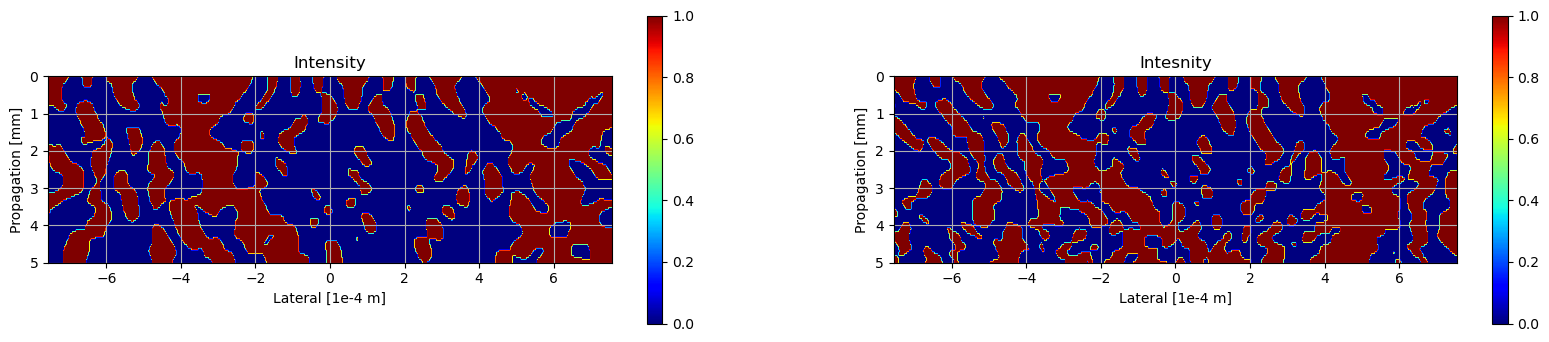

In [124]:
fig, axs = plt.subplots(1, 2, figsize=(20, 4))

cm0 = axs[0].imshow(gaussian_filter(np.log10(torch.abs(u_io_r[:, 1012+256:-256+2012])**2), 2)>-0.1, cmap='jet', extent=[-1*dx*(nx/2 + padding)*1e4, dx*(nx/2 + padding)*1e4, 5, 0])
plt.colorbar(cm0, ax=axs[0])
axs[0].set_ylabel('Propagation [mm]')
axs[0].set_xlabel('Lateral [1e-4 m]')
axs[0].set_title('Intensity')
axs[0].grid()

cm1 = axs[1].imshow(gaussian_filter(np.log10(torch.abs(u_io_z[:, 1012+256:-256+2012])**2), 2)>-0.1, cmap='jet', extent=[-1*dx*(nx/2 + padding)*1e4, dx*(nx/2 + padding)*1e4, 5, 0])
plt.colorbar(cm1, ax=axs[1])
axs[1].set_ylabel('Propagation [mm]')
axs[1].set_xlabel('Lateral [1e-4 m]')
axs[1].set_title('Intesnity')
axs[1].grid()

plt.show()

In [461]:
# add noise in measurements: simulated ground truth
# why peak at dist?
# cosines with harmonics
# 3 to 5 base cells
# large curvature
